# Read in float data, calculate difference relative to SOM-FFN, seasonally adjust, save back out

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats



## Directories

In [2]:
base_dir = '/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/'
argo_path = base_dir + "Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/"
plot_dir = '../float_pco2_plots/'
pco2_output_dir =  base_dir + "Datasets/Data_Products/CO2_fluxes/Landshuster_Neural/" 
os.path.isdir(argo_path)


True

Load mapped pCO2 product(s)

In [3]:
vliz = xr.open_dataset(pco2_output_dir + '2024_02/VLIZ-SOM_FFN_vSOCCOM2024v2.nc')
vliz

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 504, lat: 180, lon: 360, bnds: 2, date: 6)
Coordinates:
  * time            (time) datetime64[ns] 4kB 1982-01-15 ... 2023-12-15
  * lat             (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon             (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
    date            (time, date) float32 12kB ...
Dimensions without coordinates: bnds
Data variables:
    dco2            (time, lat, lon) float32 131MB ...
    atm_co2         (time, lat, lon) float32 131MB ...
    sol             (time, lat, lon) float32 131MB ...
    seaice          (time, lat, lon) float32 131MB ...
    kw              (time, lat, lon) float32 131MB ...
    spco2_raw       (time, lat, lon) float32 131MB ...
    spco2_smoothed  (time, lat, lon) float32 131MB ...
    fgco2_raw       (time, lat, lon) float32 131MB ...
    fgco2_smoothed  (time, lat, lon) float32 131MB ...
    time_bnds       (time, bnds) datetime64[ns] 8kB ...
    lat_bnds        (lat, bnds) float32 1kB ...
    lon_bnds        (lon, bnds) float32 3kB ...
Attributes:
    institution:    Flanders Marine Institute (VLIZ), Ostend, Belgium
    institude_id:   MPI-M
    model_id:       SOM-FFN
    run_id:         SOM_FFN_vSOCCOM2024v2
    contact:        Peter Landschutzer (peter.landschutzer@vliz.be)
    creation_date:  2024-02-09

In [ ]:
# find processed files
argolist = []
for file in os.listdir(argo_path):
    if file.endswith('processed.nc'):
        argolist.append(file)

print(len(argolist))
ph_var = 'PH_IN_SITU_TOTAL_ADJUSTED_RO'
# find floats that have valid pH
float_pH_list = []
for n, file in enumerate(argolist):
    argo_n = xr.open_dataset(argo_path + file)
    if ph_var in argo_n.keys():
        if np.sum(~np.isnan(argo_n[ph_var]))>0:
            float_pH_list.append(file)
float_pH_list = np.sort(float_pH_list)               
print(len(float_pH_list))

1934


## calculate ML pCO2 for each float, match to gridded product, plot
- Save into a dataframe that you will then use for gridding
 - Find summer offsets and create an adjusted dataset if there is enough data


In [7]:
import warnings 
pco2_df = []

save_plot = 0 

for idx, file in enumerate(float_pH_list):
    # file = '5904677_Sprof_processed.nc'
    argo_n = xr.open_dataset(argo_path + file)
    
    # initialize ml_pCO2 variable
    pco2_var = 'pCO2_ESPER_MX'
    argo_n['ML_PCO2'] = (['N_PROF'],np.empty(argo_n['MLD'].shape)) #nprof x nlevel
    argo_n.ML_PCO2[:] = np.nan
    argo_n['mapped_pCO2_matched'] = (['N_PROF'],np.empty(argo_n['MLD'].shape)) #nprof x nlevel
    argo_n.mapped_pCO2_matched[:] = np.nan

    for p in argo_n['N_PROF'].values:
    # print(argo_n['PRES_ADJUSTED_RO'][p,:].values)
    # print(argo_n['PH_IN_SITU_TOTAL_ADJUSTED_RO'][p,:].values)
    # print(argo_n['MLD'][:])
    # calculating mean of ml pCO2 for upper 90% of the ML

        ml_pCO2 = argo_n[pco2_var][p,:].where(argo_n['PRES_ADJUSTED_RO'][p,:]<argo_n['MLD'][p].values - argo_n['MLD'][p].values*.1).values
        # print(np.nanmean(ml_pCO2))
        with warnings.catch_warnings():
            warnings.filterwarnings(action="ignore", message='Mean of empty slice')
            argo_n.ML_PCO2[p] = np.nanmean(ml_pCO2)

    interpolated_mapped_pco2 = vliz['spco2_smoothed'].interp(time=('points', argo_n['JULD'].values),
                                                lat=('points', argo_n['LATITUDE'].values),
                                                lon=('points', argo_n['LONGITUDE'].values)
    )
        # print(mean)
    interpolated_mapped_pco2 = interpolated_mapped_pco2.rename({'points': 'N_PROF'})
    argo_n.mapped_pCO2_matched[:] = interpolated_mapped_pco2    

    pco2_diff = argo_n['ML_PCO2']-argo_n['mapped_pCO2_matched']
    if argo_n['LATITUDE'].mean(skipna=True)>15:
        months_comp = [6, 7 ,8]
    elif argo_n['LATITUDE'].mean(skipna=True)<-15:
        months_comp = [1, 2, 3]
    else:
        months_comp = [1, 12]
    comp_month_index = np.logical_and(argo_n['JULD'].dt.month>=months_comp[0], argo_n['JULD'].dt.month<=months_comp[-1])
    
    # isolate non-nan differences b/t float pCO2 and comparison month values 

    diff_temp = pco2_diff[comp_month_index]
    if np.sum(~np.isnan(diff_temp))>0:
         
        time_temp = argo_n['JULD'][comp_month_index]

        diff_no_nan = diff_temp[np.logical_and(~np.isnan(diff_temp), ~np.isnan(time_temp))].values
        time_no_nan = time_temp[np.logical_and(~np.isnan(diff_temp), ~np.isnan(time_temp))].values
    
        # put comparison time into seconds for regression
        time_pd = pd.to_datetime(time_no_nan)
        time_sec = time_pd.values.tolist()

        # linear regression
        res = stats.linregress(time_sec, 
                            diff_no_nan)
        # plt.plot(time_sec, diff_no_nan, 'x')
        # plt.plot(time_sec, res.intercept + np.array(time_sec)*res.slope, 'r')

        # need to get values to then add back to the entire series. so replance time_sec w/ full dataset times. 
        float_dates_pd = pd.to_datetime(argo_n['JULD'].values)
        float_dates_sec = float_dates_pd.values.tolist()
        diff_to_add = res.intercept + np.array(float_dates_sec)*res.slope
        diff_to_add = diff_to_add*-1

        float_pco2_w_linear_adjustment =  argo_n['ML_PCO2']+diff_to_add
        float_pco2_w_linear_adjustment = float_pco2_w_linear_adjustment.values
        float_pco2_w_mean_adjustment = argo_n['ML_PCO2'] + pco2_diff[comp_month_index].mean(skipna=True).values*-1
        float_pco2_w_mean_adjustment = float_pco2_w_mean_adjustment.values
        if np.array([time_sec[-1]-time_sec[0]])/(10**9*60*60*24)>300: # if there are more than 300 days between the first time for the chosen pCO2 differences and the last, then use the linear adjustment
            float_pco2_chosen = float_pco2_w_linear_adjustment
        else: # otherwise use the mean 
            float_pco2_chosen = float_pco2_w_mean_adjustment
    else:
        nan_array = np.zeros((len(pco2_diff.values)))
        nan_array[:] = np.NaN
        float_pco2_w_linear_adjustment = nan_array
        float_pco2_w_mean_adjustment = nan_array
        float_pco2_chosen = nan_array
    pco2_df_n = pd.DataFrame({                 # creates a new "outlier_df" w wmo, variable name, profile, date, level, pressure, deletion reason 
                            "WMO":[argo_n['WMO_ID'].values]*len(argo_n['N_PROF']),
                            "LATITUDE":argo_n['LATITUDE'].values,
                            "LONGITUDE":argo_n['LONGITUDE'].values,
                            "JULD":argo_n['JULD'].values,
                            "Float pCO2":argo_n['ML_PCO2'].values,
                            "mapped_pCO2":argo_n['mapped_pCO2_matched'].values,
                            "pCO2_diff":pco2_diff.values,
                            "float_pco2_linear_adjustment":float_pco2_w_linear_adjustment,
                            "float_pco2_mean_adjustment":float_pco2_w_mean_adjustment,
                            "float_pco2_chosen":float_pco2_chosen,
    })
    pco2_df_n = pco2_df_n.dropna(how='any') 

    if len(pco2_df)==0:
        pco2_df = pco2_df_n
    else:
        pco2_df = pd.concat([pco2_df, pco2_df_n])


    
    if save_plot==0:
        continue

    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(3,1,1)
    ax.plot(argo_n['JULD'], argo_n['ML_PCO2'], label='ML_PCO2')
    ax.plot(argo_n['JULD'], argo_n['mapped_pCO2_matched'], label='SOM_FFN_Matched', color='orange')
    ax.set_ylabel('pco2 (uatm)')
    ax.plot(argo_n['JULD'][comp_month_index], argo_n['ML_PCO2'][comp_month_index], color='green', marker = 'x', linestyle='None', label='Comparison Months')
    x_limits = ax.get_xlim()
    plt.legend()

    fig.suptitle(str(argo_n['WMO_ID'].values) + ', Mean lat: ' + str(argo_n['LATITUDE'].mean(skipna=True).values))
    ax2 = fig.add_subplot(3,1,2)
    ax2.plot(argo_n['JULD'], pco2_diff.values, label='diff')
    ax2.grid('on')
    ax2.hlines(y=0, xmin=argo_n['JULD'][0], xmax=argo_n['JULD'][-1], colors='k', linestyles='--')
    ax2.plot(argo_n['JULD'][comp_month_index], pco2_diff[comp_month_index], \
             color='green', marker = 'x', linestyle='None', label='Comparison Months')

    ax2.set_ylabel('pco2 diff')

    ax3 = fig.add_subplot(3,1,3)
    ax3.grid('on')
    ax3.plot(argo_n['JULD'], argo_n['mapped_pCO2_matched'], label='SOM_FFN_Matched', color='orange')
    ax3.plot(argo_n['JULD'], float_pco2_w_linear_adjustment, label='ML_PCO2 plus linear correction', color='purple')
    ax3.plot(argo_n['JULD'], float_pco2_w_mean_adjustment, label='ML_PCO2 plus mean correction', color='magenta', linestyle = '--')
    ax3.plot(argo_n['JULD'], float_pco2_chosen, label='ML_PCO2 plus chosen correction', color='green', linestyle = '-.')

    ax3.set_ylabel('pco2 (uatm)')
    ax3.set_xlim(x_limits)
    plt.legend()

    plt.tight_layout()

    savename = str(argo_n['WMO_ID'].values) + '_pCO2_matched_diff.png'
    plt.savefig(plot_dir + 'individual_floats/' + savename)
    # if idx>50:
    #     break
    # plt.close(fig)

pco2_df = pco2_df.reset_index()
pco2_df_filt = pco2_df.copy()

/Users/sethbushinsky/anaconda3/envs/som_ffn/lib/python3.12/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/Users/sethbushinsky/anaconda3/envs/som_ffn/lib/python3.12/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/Users/sethbushinsky/anaconda3/envs/som_ffn/lib/python3.12/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/Users/sethbushinsky/anaconda3/envs/som_ffn/lib/python3.12/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/Users/sethbushinsky/anaconda3/envs/som_ffn/lib/python3.12/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered

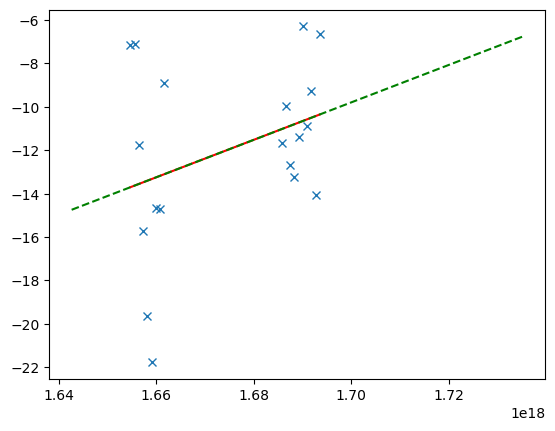

In [303]:
res = stats.linregress(time_sec, 
                           diff_no_nan)
plt.plot(time_sec, diff_no_nan, 'x')
plt.plot(time_sec, res.intercept + np.array(time_sec)*res.slope, 'r')

# need to get values to then add back to the entire series. so replance time_sec w/ full dataset times. 

float_dates_pd = pd.to_datetime(argo_n['JULD'].values)
float_dates_sec = float_dates_pd.values.tolist()

plt.plot(float_dates_sec, res.intercept + np.array(float_dates_sec)*res.slope, 'g--')

diff_to_add = res.intercept + np.array(float_dates_sec)*res.slope

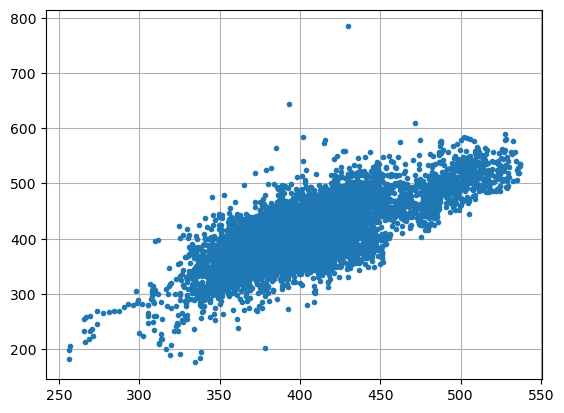

In [8]:
plt.plot(pco2_df_filt['mapped_pCO2'], pco2_df_filt['Float pCO2'], '.')
plt.grid('on')

In [10]:
# remove unrealistically high values
pco2_df_filt = pco2_df_filt.copy()
pco2_df_filt.loc[pco2_df_filt['Float pCO2']>700]=np.nan

In [75]:
plot_dir

'../float_pco2_plots/'

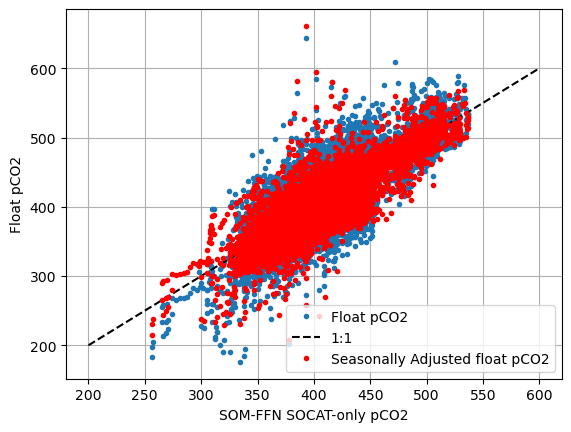

In [76]:

# plot to check
plt.plot(pco2_df_filt['mapped_pCO2'], pco2_df_filt['Float pCO2'], '.', label='Float pCO2')
plt.grid('on')
plt.plot([200, 600], [200,600], color='k', linestyle='--', label='1:1')
plt.plot(pco2_df_filt['mapped_pCO2'], pco2_df_filt['float_pco2_chosen'], '.r', label='Seasonally Adjusted float pCO2')
plt.xlabel('SOM-FFN SOCAT-only pCO2')
plt.ylabel('Float pCO2')
plt.legend()

plt.savefig('../output-plots/' + 'float pco2 vs mapped socat pco2.png' )




## Load SOCAT gridded data

In [12]:
socat = xr.open_dataset(base_dir + 'Datasets/Data_Products/SOCAT/v2024/SOCATv2024_tracks_gridded_monthly.nc')
socat

<xarray.Dataset> Size: 5GB
Dimensions:                (xlon: 360, ylat: 180, tmnth: 648, bnds: 2)
Coordinates:
  * xlon                   (xlon) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * ylat                   (ylat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * tmnth                  (tmnth) datetime64[ns] 5kB 1970-01-16T12:00:00 ......
Dimensions without coordinates: bnds
Data variables: (12/25)
    tmnth_bnds             (tmnth, bnds) datetime64[ns] 10kB ...
    count_ncruise          (tmnth, ylat, xlon) float64 336MB ...
    fco2_count_nobs        (tmnth, ylat, xlon) float64 336MB ...
    fco2_ave_weighted      (tmnth, ylat, xlon) float32 168MB ...
    fco2_ave_unwtd         (tmnth, ylat, xlon) float32 168MB ...
    fco2_min_unwtd         (tmnth, ylat, xlon) float32 168MB ...
    ...                     ...
    salinity_min_unwtd     (tmnth, ylat, xlon) float32 168MB ...
    salinity_max_unwtd     (tmnth, ylat, xlon) float32 168MB ...
    salinity_std_weighted  (tmnth, ylat, xlon) float32 168MB ...
    salinity_std_unwtd     (tmnth, ylat, xlon) float32 168MB ...
    lat_offset_unwtd       (tmnth, ylat, xlon) float32 168MB ...
    lon_offset_unwtd       (tmnth, ylat, xlon) float32 168MB ...
Attributes:
    history:      PyFerret V7.63 (optimized) 29-Apr-24
    Conventions:  CF-1.6
    title:        SOCAT gridded v2024 Monthly 1x1 degree gridded dataset
    summary:      Surface Ocean Carbon Atlas (SOCAT) Gridded (binned) SOCAT o...
    references:   http://www.socat.info/
    SOCAT_Notes:  SOCAT gridded v2024 29-Apr-2024
    caution:      NO INTERPOLATION WAS PERFORMED. SIGNIFICANT BIASES ARE PRES...

In [39]:
import functions.grid_pCO2_data as grid_pCO2_data
from multiprocessing import Pool

# preparing for monthly gridding using parallel processing:

socat_metadata = xr.Dataset()
socat_metadata['tmnth_bnds'] = socat.tmnth_bnds.copy()
socat_metadata['xlon'] = socat.xlon.copy()
socat_metadata['ylat'] = socat.ylat.copy()

num_processes = 7

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        grid_args = [(pco2_df_filt, socat_metadata, t_i) for t_i in range(504, len(socat.tmnth))]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(grid_pCO2_data.grid_pCO2_data, grid_args)
    

# grid_pCO2_data.grid_pCO2_data(pco2_df_filt, socat_metadata, t_i)

In [ ]:
# # original - REPLACED BY SEPARATE PYTHON FILE
# pco2_float_gridded = np.zeros((len(socat.tmnth), len(socat['ylat']), len(socat['xlon'])))
# pco2_float_gridded[:] = np.NaN
# pco2_float_adjusted_gridded = np.zeros((len(socat.tmnth), len(socat['ylat']), len(socat['xlon'])))
# pco2_float_adjusted_gridded[:] = np.NaN

# for t_i in range(600, 601):#range(504, len(socat.tmnth)): # starting in Jan 2012
#     time_index = np.logical_and(pco2_df_filt['JULD']>=socat.tmnth_bnds[t_i][0].values, pco2_df_filt['JULD']<socat.tmnth_bnds[t_i][1].values)
#     if len(pco2_df_filt[time_index])==0:
#         continue
#     print(socat.tmnth_bnds[t_i].values)
#     # grid the float data to the same grid as socat
#     for x_i in range(0, len(socat['xlon'])):
#         for y_i in range(13, 166):
#             # print(socat['xlon'][x_i].values)
#             lon_index = np.logical_and(pco2_df_filt['LONGITUDE']>=socat['xlon'][x_i].values-0.5, pco2_df_filt['LONGITUDE']<socat['xlon'][x_i].values+0.5)
#             # pco2_df_filt[lon_index]

#             # y_i = 100
#             # print(socat['ylat'][y_i].values)

#             lat_index = np.logical_and(pco2_df_filt['LATITUDE']>=socat['ylat'][y_i].values-0.5, pco2_df_filt['LATITUDE']<socat['ylat'][y_i].values+0.5)
#             # pco2_df_filt[lat_index]

#             grid_index = np.logical_and(lat_index,lon_index)
#             grid_index = np.logical_and(grid_index,time_index)

#             pco2_float_gridded[t_i, y_i, x_i] = np.nanmean(pco2_df_filt[grid_index]['Float pCO2'])
#             pco2_float_adjusted_gridded[t_i, y_i, x_i] = np.nanmean(pco2_df_filt[grid_index]['float_pco2_chosen'])

#             # print(pco2_float_gridded[t_i, x_i, y_i])
    

['2020-01-01T00:00:00.000000000' '2020-02-01T00:00:00.000000000']


/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_94921/3861414906.py:28: RuntimeWarning: Mean of empty slice
  pco2_float_gridded[t_i, y_i, x_i] = np.nanmean(pco2_df_filt[grid_index]['Float pCO2'])
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_94921/3861414906.py:29: RuntimeWarning: Mean of empty slice
  pco2_float_adjusted_gridded[t_i, y_i, x_i] = np.nanmean(pco2_df_filt[grid_index]['float_pco2_chosen'])


In [40]:
# load monthly gridded data:
pco2_float_gridded = np.zeros((len(socat.tmnth), len(socat['ylat']), len(socat['xlon'])))
pco2_float_gridded[:] = np.NaN
pco2_float_adjusted_gridded = np.zeros((len(socat.tmnth), len(socat['ylat']), len(socat['xlon'])))
pco2_float_adjusted_gridded[:] = np.NaN

# loop through each month, loading files and saving into the arrays
for t_i in range(504, len(socat.tmnth)):
    month_pd = pd.to_datetime(socat.tmnth_bnds[t_i][0].values)
    base_filename = '../intermediate_data/' + str(month_pd.year) + '_' + str(month_pd.month)

    month_pco2_float_gridded = np.load(base_filename + '_pco2_float_gridded.npy')
    month_pco2_float_gridded_adjusted = np.load(base_filename + '_pco2_float_adjusted_gridded.npy')

    pco2_float_gridded[t_i,:,:] = month_pco2_float_gridded
    pco2_float_adjusted_gridded[t_i,:,:] = month_pco2_float_gridded_adjusted

# merge gridded data w/ socat 
socat['pco2_float_gridded'] = (( 'tmnth', 'ylat','xlon'), pco2_float_gridded)
socat['pco2_float_adjusted_gridded'] = (( 'tmnth', 'ylat','xlon'), pco2_float_adjusted_gridded)

float_socat_mean = np.nanmean((socat['fco2_ave_weighted'][:,:,:], socat['pco2_float_gridded'][:,:,:]), axis=0)
float_adjusted_socat_mean = np.nanmean((socat['fco2_ave_weighted'][:,:,:], socat['pco2_float_adjusted_gridded'][:,:,:]), axis=0)

socat['float_socat_mean'] = (( 'tmnth', 'ylat','xlon'), float_socat_mean)
socat['float_adjusted_socat_mean'] = (( 'tmnth', 'ylat','xlon'), float_adjusted_socat_mean)

/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_94921/1131728661.py:22: RuntimeWarning: Mean of empty slice
  float_socat_mean = np.nanmean((socat['fco2_ave_weighted'][:,:,:], socat['pco2_float_gridded'][:,:,:]), axis=0)
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_94921/1131728661.py:23: RuntimeWarning: Mean of empty slice
  float_adjusted_socat_mean = np.nanmean((socat['fco2_ave_weighted'][:,:,:], socat['pco2_float_adjusted_gridded'][:,:,:]), axis=0)


In [70]:
socat.to_netcdf('../intermediate_data/_socat_w_float.nc')

In [71]:
socat

<xarray.Dataset> Size: 6GB
Dimensions:                      (xlon: 360, ylat: 180, tmnth: 648, bnds: 2)
Coordinates:
  * xlon                         (xlon) float64 3kB -179.5 -178.5 ... 179.5
  * ylat                         (ylat) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * tmnth                        (tmnth) datetime64[ns] 5kB 1970-01-16T12:00:...
Dimensions without coordinates: bnds
Data variables: (12/29)
    tmnth_bnds                   (tmnth, bnds) datetime64[ns] 10kB ...
    count_ncruise                (tmnth, ylat, xlon) float64 336MB ...
    fco2_count_nobs              (tmnth, ylat, xlon) float64 336MB ...
    fco2_ave_weighted            (tmnth, ylat, xlon) float32 168MB ...
    fco2_ave_unwtd               (tmnth, ylat, xlon) float32 168MB ...
    fco2_min_unwtd               (tmnth, ylat, xlon) float32 168MB ...
    ...                           ...
    lat_offset_unwtd             (tmnth, ylat, xlon) float32 168MB ...
    lon_offset_unwtd             (tmnth, ylat, xlon) float32 168MB ...
    pco2_float_gridded           (tmnth, ylat, xlon) float64 336MB nan ... nan
    pco2_float_adjusted_gridded  (tmnth, ylat, xlon) float64 336MB nan ... nan
    float_socat_mean             (tmnth, ylat, xlon) float64 336MB nan ... nan
    float_adjusted_socat_mean    (tmnth, ylat, xlon) float64 336MB nan ... nan
Attributes:
    history:      PyFerret V7.63 (optimized) 29-Apr-24
    Conventions:  CF-1.6
    title:        SOCAT gridded v2024 Monthly 1x1 degree gridded dataset
    summary:      Surface Ocean Carbon Atlas (SOCAT) Gridded (binned) SOCAT o...
    references:   http://www.socat.info/
    SOCAT_Notes:  SOCAT gridded v2024 29-Apr-2024
    caution:      NO INTERPOLATION WAS PERFORMED. SIGNIFICANT BIASES ARE PRES...

(array([ 12.,  17.,  57., 191., 371., 248., 401.,  86.,  22.,   4.]),
 array([159.10144043, 199.37261963, 239.64381409, 279.91500854,
        320.18618774, 360.45736694, 400.72854614, 440.99972534,
        481.27093506, 521.54211426, 561.81329346]),
 <BarContainer object of 10 artists>)

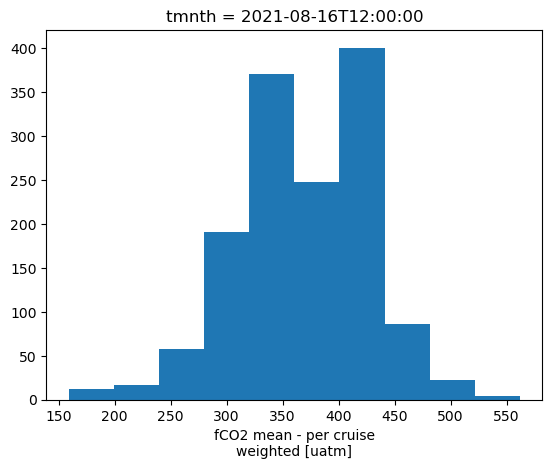

In [57]:
t_i = 619
socat['fco2_ave_weighted'][t_i,:,:].plot.hist()

In [54]:
# plotting of gridded months and data
font_size = 28

v_min = 300
v_max = 500

y_grid, x_grid = np.meshgrid(socat['ylat'], socat['xlon'])
for t_i in range(619, 620):
    # plots - pco2 socat, pco2 float (raw), pco2 float (gridded), pco2_float_adjusted, mean pco2_float+socat, mean pco2_float_adjusted+socat, diffs
    fig = plt.figure(figsize=(35,35))


    month_pd = pd.to_datetime(socat.tmnth_bnds[t_i][0].values)

    plot_filename = 'pCO2_gridding_' + str(month_pd.year) + '-' + str(month_pd.month)
    data_proj = ccrs.PlateCarree()

    # find the float data that match this month 
    time_index = np.logical_and(pco2_df_filt['JULD']>=socat.tmnth_bnds[t_i][0].values, pco2_df_filt['JULD']<socat.tmnth_bnds[t_i][1].values)

    pco2_df_filt[time_index]

    ax1 = fig.add_subplot(3,2,1, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax1.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))

    ax1.set_global()

    sc1 = ax1.scatter(pco2_df_filt[time_index]['LONGITUDE'], pco2_df_filt[time_index]['LATITUDE'],  c=pco2_df_filt[time_index]['Float pCO2'], transform=data_proj, vmin=v_min, vmax=v_max)
    cbar = fig.colorbar(sc1, ax=ax1, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax1.set_title('Float pCO2', fontsize=font_size)

    ax2 = fig.add_subplot(3,2,2, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax2.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))

    ax2.set_global()
    # ax1.coastlines()
    # ax1.set_global()
    pmesh = ax2.pcolormesh(x_grid, y_grid, socat['pco2_float_gridded'][t_i,:,:].squeeze().T, transform = data_proj, vmin=v_min, vmax=v_max)
    # cbar = fig.colorbar(pmesh, ax=ax, orientation='horizontal')#, fraction=0.1, aspect=40, pad=0.08)
    cbar = fig.colorbar(pmesh, ax=ax2, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax2.set_title('Gridded float pCO2', fontsize=font_size)

    ax3 = fig.add_subplot(3,2,3, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax3.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))

    ax3.set_global()
    # ax1.coastlines()
    # ax1.set_global()
    pmesh = ax3.pcolormesh( x_grid, y_grid,socat['fco2_ave_weighted'][t_i,:,:].squeeze().T.values, transform = data_proj, vmin=v_min, vmax=v_max)
    # cbar = fig.colorbar(pmesh, ax=ax, orientation='horizontal')#, fraction=0.1, aspect=40, pad=0.08)
    cbar = fig.colorbar(pmesh, ax=ax3, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax3.set_title('SOCAT fCO2', fontsize=font_size)

    ax4 = fig.add_subplot(3,2,4, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax4.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
    ax4.set_global()
    pmesh = ax4.pcolormesh( x_grid, y_grid,socat['float_socat_mean'][t_i,:,:].squeeze().T, transform = data_proj, vmin=v_min, vmax=v_max)
    cbar = fig.colorbar(pmesh, ax=ax4, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax4.set_title('Float + Socat mean', fontsize=font_size)

    ax5 = fig.add_subplot(3,2,5, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax5.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
    ax5.set_global()
    diff_bt_gridded_float_and_adjusted = socat['pco2_float_gridded'][t_i,:,:].squeeze().T - socat['pco2_float_adjusted_gridded'][t_i,:,:].squeeze().T
    pmesh = ax5.pcolormesh( x_grid, y_grid, diff_bt_gridded_float_and_adjusted, transform = data_proj, cmap='RdBu', vmin=-40, vmax=40)
    cbar = fig.colorbar(pmesh, ax=ax5, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax5.set_title('Diff bt gridded float and gridded adjusted float', fontsize=font_size)


    ax6 = fig.add_subplot(3,2,6, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax6.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
    ax6.set_global()
    diff_bt_gridded_merged_and_gridded_merged_adjusted = socat['float_socat_mean'][t_i,:,:].squeeze().T - socat['float_adjusted_socat_mean'][t_i,:,:].squeeze().T
    pmesh = ax6.pcolormesh( x_grid, y_grid, diff_bt_gridded_merged_and_gridded_merged_adjusted, transform = data_proj, cmap='RdBu', vmin=-40, vmax=40)
    cbar = fig.colorbar(pmesh, ax=ax6, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)
    ax6.set_title('Diff bt float+SOCAT and adjusted float+socat', fontsize=font_size)
    fig.suptitle(str(month_pd.year) + '-' + str(month_pd.month), fontsize=font_size)


    plt.tight_layout()

    plt.savefig(plot_dir + plot_filename)
    plt.close(fig)


In [60]:
socat

<xarray.Dataset> Size: 6GB
Dimensions:                      (xlon: 360, ylat: 180, tmnth: 648, bnds: 2)
Coordinates:
  * xlon                         (xlon) float64 3kB -179.5 -178.5 ... 179.5
  * ylat                         (ylat) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * tmnth                        (tmnth) datetime64[ns] 5kB 1970-01-16T12:00:...
Dimensions without coordinates: bnds
Data variables: (12/29)
    tmnth_bnds                   (tmnth, bnds) datetime64[ns] 10kB ...
    count_ncruise                (tmnth, ylat, xlon) float64 336MB ...
    fco2_count_nobs              (tmnth, ylat, xlon) float64 336MB ...
    fco2_ave_weighted            (tmnth, ylat, xlon) float32 168MB ...
    fco2_ave_unwtd               (tmnth, ylat, xlon) float32 168MB ...
    fco2_min_unwtd               (tmnth, ylat, xlon) float32 168MB ...
    ...                           ...
    lat_offset_unwtd             (tmnth, ylat, xlon) float32 168MB ...
    lon_offset_unwtd             (tmnth, ylat, xlon) float32 168MB ...
    pco2_float_gridded           (tmnth, ylat, xlon) float64 336MB nan ... nan
    pco2_float_adjusted_gridded  (tmnth, ylat, xlon) float64 336MB nan ... nan
    float_socat_mean             (tmnth, ylat, xlon) float64 336MB nan ... nan
    float_adjusted_socat_mean    (tmnth, ylat, xlon) float64 336MB nan ... nan
Attributes:
    history:      PyFerret V7.63 (optimized) 29-Apr-24
    Conventions:  CF-1.6
    title:        SOCAT gridded v2024 Monthly 1x1 degree gridded dataset
    summary:      Surface Ocean Carbon Atlas (SOCAT) Gridded (binned) SOCAT o...
    references:   http://www.socat.info/
    SOCAT_Notes:  SOCAT gridded v2024 29-Apr-2024
    caution:      NO INTERPOLATION WAS PERFORMED. SIGNIFICANT BIASES ARE PRES...

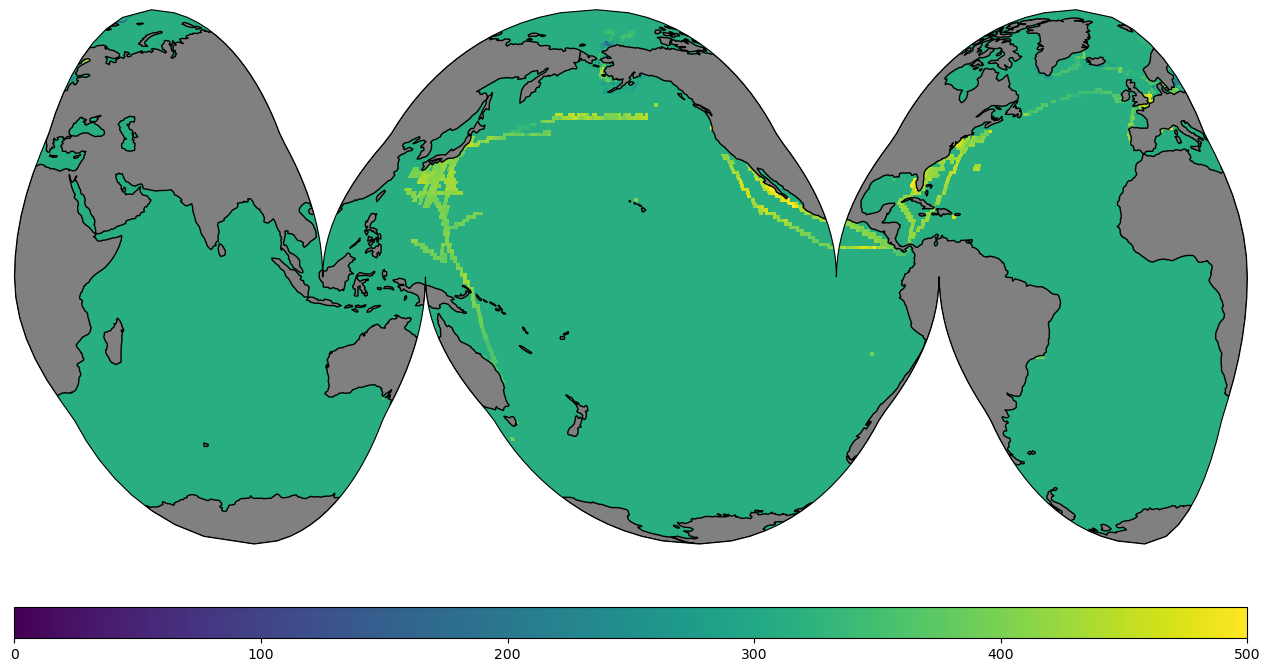

In [ ]:
t_i = 619
fig = plt.figure(figsize=(35,35))

ax3 = fig.add_subplot(3,2,3, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
ax3.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))

ax3.set_global()
# ax1.coastlines()
# ax1.set_global()
pmesh = ax3.pcolormesh( x_grid, y_grid,socat['fco2_ave_unwtd'][t_i,:,:].squeeze().T.values, transform = data_proj, vmin=0, vmax=v_max)
# cbar = fig.colorbar(pmesh, ax=ax, orientation='horizontal')#, fraction=0.1, aspect=40, pad=0.08)
cbar = fig.colorbar(pmesh, ax=ax3, orientation='horizontal', fraction=0.1, aspect=40, pad=0.08)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([450.45977783, 450.72781372, 450.99584961, 451.26391602,
        451.5319519 , 451.79998779, 452.06802368, 452.33605957,
        452.60412598, 452.87216187, 453.14019775]),
 <BarContainer object of 10 artists>)

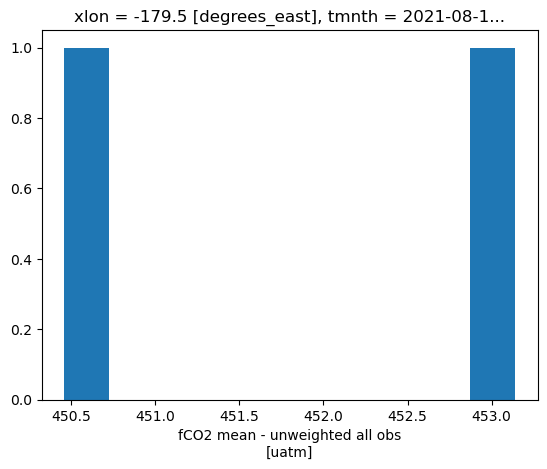